#### 1. Image Enhancement

In [1]:
import os
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
from ultralytics import YOLO
import matplotlib.pyplot as plt
from skimage.util import random_noise
from skimage.filters import gaussian
from skimage import morphology
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from skimage.restoration import inpaint
from sklearn.decomposition import PCA
from skimage.filters import threshold_otsu
from scipy.stats import entropy as scipy_entropy

In [2]:
# Load image
image = cv2.imread('Unenhanced.png')  
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [3]:
# 1. Histogram Equalization
equalized = cv2.equalizeHist(image_gray)

# 2. Sharpening (using kernel)
kernel_sharpen = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])
sharpened = cv2.filter2D(image_rgb, -1, kernel_sharpen)

# 3. Add Gaussian Noise
noise_image = random_noise(image, mode='gaussian', var=0.025)
noise_image = (noise_image * 255).astype(np.uint8)

# 4. Gaussian Smoothing
sigma = 2
smoothed_image = gaussian(noise_image, channel_axis=-1, sigma=sigma)
smoothed_image = (smoothed_image * 255).astype(np.uint8)


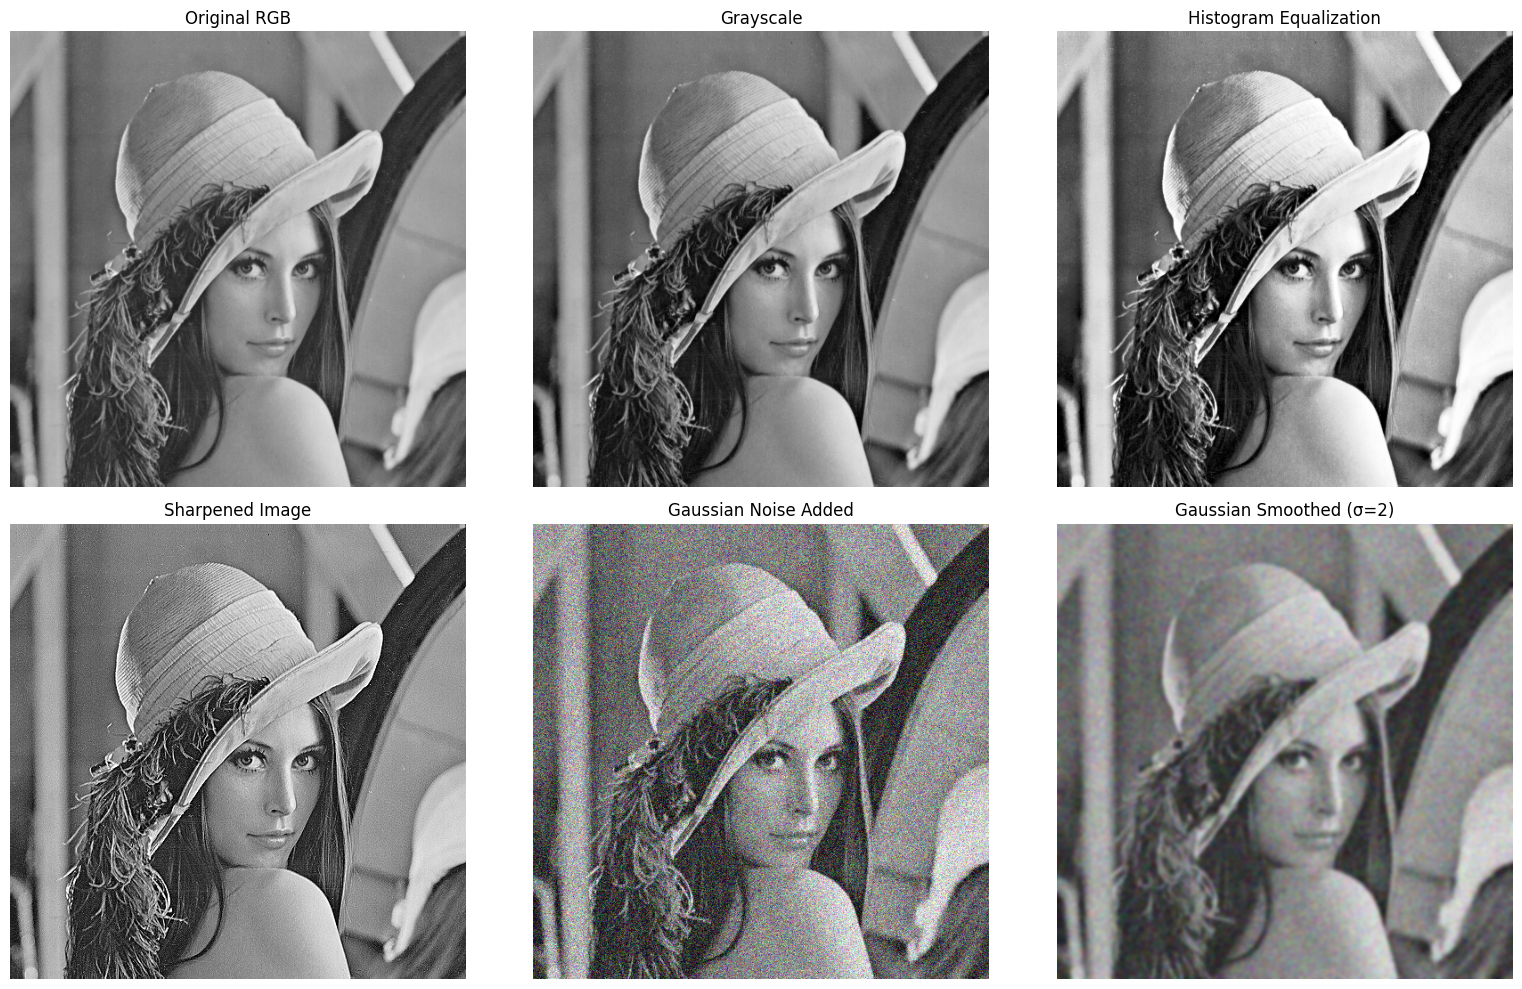

In [4]:
# Plot using classic subplot notation
plt.figure(figsize=(16, 10))

plt.subplot(231)
plt.imshow(image)
plt.title('Original RGB')
plt.axis('off')

plt.subplot(232)
plt.imshow(image_gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

plt.subplot(233)
plt.imshow(equalized, cmap='gray')
plt.title('Histogram Equalization')
plt.axis('off')

plt.subplot(234)
plt.imshow(sharpened)
plt.title('Sharpened Image')
plt.axis('off')

plt.subplot(235)
plt.imshow(noise_image)
plt.title('Gaussian Noise Added')
plt.axis('off')

plt.subplot(236)
plt.imshow(smoothed_image)
plt.title(f'Gaussian Smoothed (σ={sigma})')
plt.axis('off')

plt.tight_layout()
plt.show()


Mask shape: (512, 512)


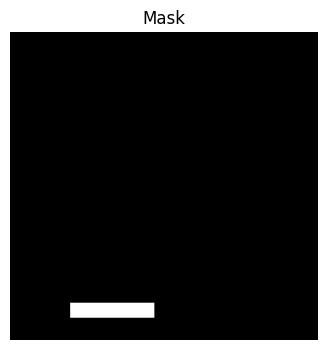

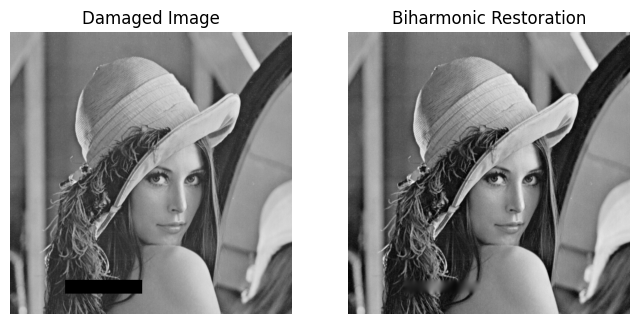

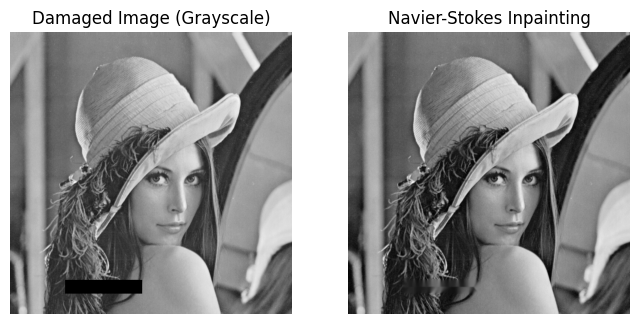

In [5]:
# 2. Image Restoration
mask = np.zeros(image.shape[:2], dtype=np.uint8)
mask[450:475, 100:240] = 1  # Region to inpaint
print("Mask shape:", mask.shape)

plt.figure(figsize=(6,4))
plt.axis('off')
plt.title("Mask")
plt.imshow(mask, cmap='gray')
plt.show()

# 2. Create damaged image by setting masked pixels to 0 (black)
damaged_image = image.copy()
damaged_image[mask == 1] = 0

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.axis('off')
plt.title("Damaged Image")
plt.imshow(damaged_image)

# 3. Biharmonic inpainting expects grayscale float image [0,1]
# Convert damaged image to grayscale float [0,1]
damaged_gray = cv2.cvtColor(damaged_image, cv2.COLOR_RGB2GRAY) / 255.0

restored_biharmonic = inpaint.inpaint_biharmonic(damaged_gray, mask)

plt.subplot(1,2,2)
plt.axis('off')
plt.title("Biharmonic Restoration")
plt.imshow(restored_biharmonic, cmap='gray')
plt.show()

# 4. Navier-Stokes inpainting (OpenCV) - input must be uint8 grayscale or color
damaged_gray_uint8 = (damaged_gray * 255).astype(np.uint8)
mask_255 = (mask * 255).astype(np.uint8)

inpainted_ns = cv2.inpaint(damaged_gray_uint8, mask_255, inpaintRadius=3, flags=cv2.INPAINT_NS)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.axis('off')
plt.title("Damaged Image (Grayscale)")
plt.imshow(damaged_gray, cmap='gray')

plt.subplot(1,2,2)
plt.axis('off')
plt.title("Navier-Stokes Inpainting")
plt.imshow(inpainted_ns, cmap='gray')
plt.show()

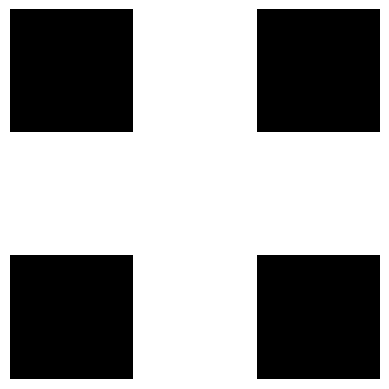

In [6]:
# 3. Morphological Operation 

#Morphological Operation
shape_disk = morphology.disk(1)

plt.axis('off')
plt.imshow(shape_disk, cmap = 'gray')

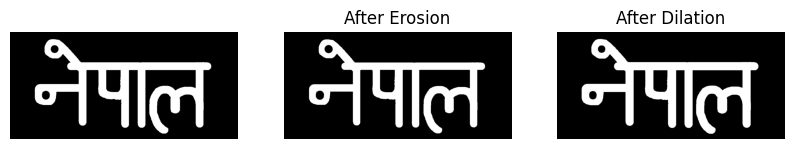

In [7]:
image_morph = imread('Image_Morph.png')
image_morph = image_morph[:, :, :3]

gray = rgb2gray(image_morph)
thresh = threshold_otsu(gray)
binary = gray > thresh
erosion = morphology.binary_erosion(binary, footprint=shape_disk)
dilation = morphology.binary_dilation(binary, footprint=shape_disk)

plt.figure(figsize=(10,10))
plt.subplot(1,3,1)
plt.axis('off')
plt.imshow(image_morph, cmap ='gray')

plt.subplot(1,3,2)
plt.axis('off')
plt.title('After Erosion')
plt.imshow(erosion, cmap = 'gray')

plt.subplot(1,3,3)
plt.axis('off')
plt.title('After Dilation')
plt.imshow(dilation, cmap = 'gray')

e:\Image_Processing\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
e:\Image_Processing\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


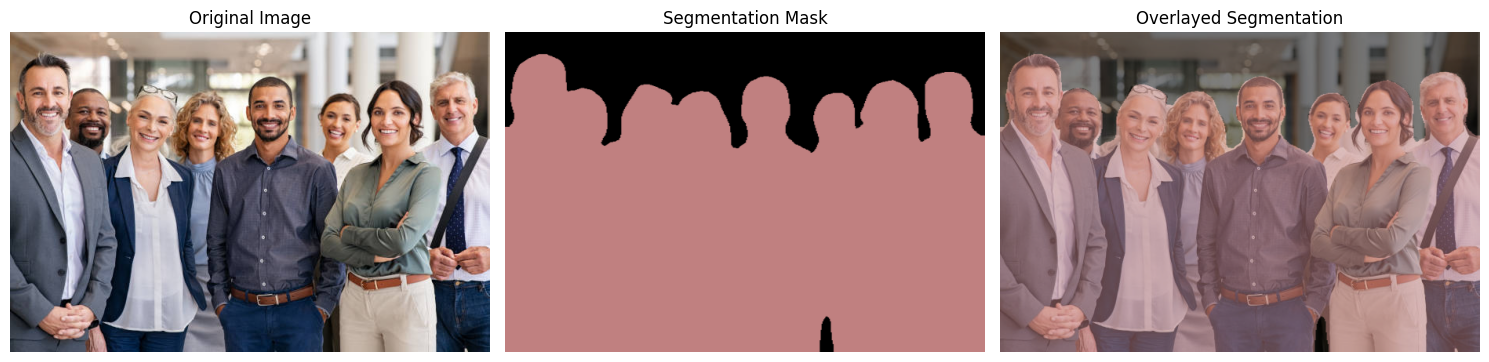

In [8]:
# 4. Image Segmentation

# Load the pre-trained DeepLabV3 model
model = deeplabv3_resnet101(pretrained=True)
model.eval()

# Load and preprocess image
img_path = 'Unsegmented.png' 
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Define transforms: resize, to tensor, normalize
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

input_tensor = transform(img_rgb).unsqueeze(0)  # Add batch dimension

# Run inference
with torch.no_grad():
    output = model(input_tensor)['out'][0]
    seg_map = output.argmax(0).byte().cpu().numpy()

# Generate a color palette for 21 classes (Pascal VOC)
def decode_segmap(seg, n_classes=21):
    label_colors = np.array([
        (0, 0, 0),       # 0=background
        (128, 0, 0),     # 1=aeroplane
        (0, 128, 0),     # 2=bicycle
        (128, 128, 0),   # 3=bird
        (0, 0, 128),     # 4=boat
        (128, 0, 128),   # 5=bottle
        (0, 128, 128),   # 6=bus
        (128, 128, 128), # 7=car
        (64, 0, 0),      # 8=cat
        (192, 0, 0),     # 9=chair
        (64, 128, 0),    # 10=cow
        (192, 128, 0),   # 11=dining table
        (64, 0, 128),    # 12=dog
        (192, 0, 128),   # 13=horse
        (64, 128, 128),  # 14=motorbike
        (192, 128, 128), # 15=person
        (0, 64, 0),      # 16=potted plant
        (128, 64, 0),    # 17=sheep
        (0, 192, 0),     # 18=sofa
        (128, 192, 0),   # 19=train
        (0, 64, 128)     # 20=tv/monitor
    ])
    r = np.zeros_like(seg).astype(np.uint8)
    g = np.zeros_like(seg).astype(np.uint8)
    b = np.zeros_like(seg).astype(np.uint8)
    
    for l in range(0, n_classes):
        idx = seg == l
        r[idx] = label_colors[l, 0]
        g[idx] = label_colors[l, 1]
        b[idx] = label_colors[l, 2]

    return np.stack([r, g, b], axis=2)

seg_colored = decode_segmap(seg_map)

# Resize segmentation mask back to original size
seg_colored_resized = cv2.resize(seg_colored, (img_rgb.shape[1], img_rgb.shape[0]))

# Overlay mask on original image (50% transparent)
overlay = cv2.addWeighted(img_rgb, 0.5, seg_colored_resized, 0.5, 0)

# Plot
plt.figure(figsize=(15, 6))

plt.subplot(131)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')

plt.subplot(132)
plt.imshow(seg_colored_resized)
plt.title("Segmentation Mask")
plt.axis('off')

plt.subplot(133)
plt.imshow(overlay)
plt.title("Overlayed Segmentation")
plt.axis('off')

plt.tight_layout()
plt.show()

PRO TIP  Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.


0: 384x640 3 persons, 1 bird, 111.6ms
Speed: 6.3ms preprocess, 111.6ms inference, 246.3ms postprocess per image at shape (1, 3, 384, 640)
Detected person with confidence 0.67
Detected person with confidence 0.54
Detected person with confidence 0.38
Detected bird with confidence 0.38


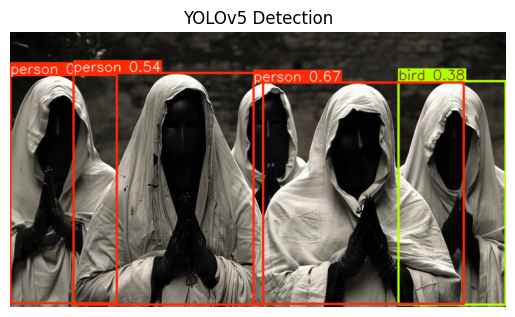

In [9]:
# 5. Image Recognition
# Load pre-trained YOLOv5s model
model = YOLO("yolov5s.pt")

# Load and preprocess image
img_path = "Cult.png"
image = cv2.imread(img_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 1. Run inference
results = model(image_rgb)

# 2. PASTE HERE: Analyze detected objects
for box in results[0].boxes:
    cls_id = int(box.cls[0])           # Class index (e.g., 0 = person)
    conf = float(box.conf[0])          # Confidence score
    label = model.names[cls_id]        # Class label (e.g., "person")
    print(f"Detected {label} with confidence {conf:.2f}")

# 3. Plot annotated result
annotated_img = results[0].plot()
plt.imshow(annotated_img)
plt.title("YOLOv5 Detection")
plt.axis('off')
plt.show()


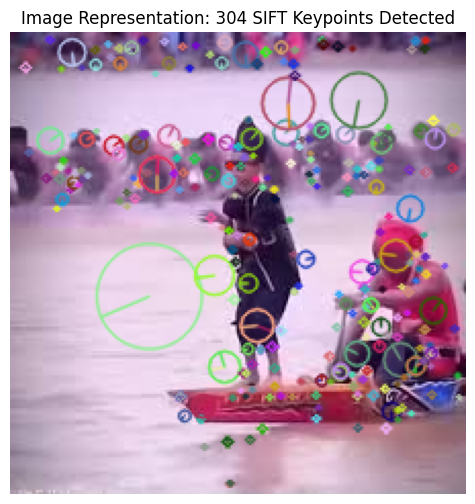

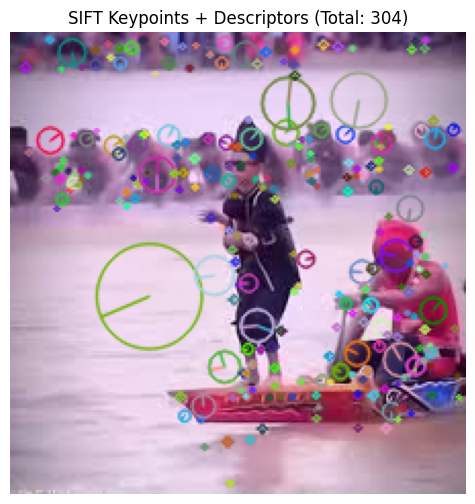


Shape of descriptor array: (304, 128)
Each row = 1 keypoint descriptor (128 features)

First 3 descriptors:

[[          7           7          38          19          27          23           6           9         103           9           1           2           7          13          14         117         161          15           0           0           0           0           0          98         161          39
            0           0           0           0           0          10         106          38          37           2           0           0           0           9         123          70          24           8           1           0           0          24         161         109           3           0
            0           0           0          12         146          67           1           0           0           0           0           1         112           8           1           1           0           0           0          11         100         

In [10]:
# 6. "Image representation and description" implementation on an image

# Image Representation (keypoints)
# Load image
img = cv2.imread("Aura.png")  
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Initialize SIFT detector
sift = cv2.SIFT_create()

# Detect keypoints (but not descriptors yet)
keypoints = sift.detect(gray, None)

# Draw keypoints on image
img_kp = cv2.drawKeypoints(img, keypoints, None,
                           flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Plot keypoints image
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(img_kp, cv2.COLOR_BGR2RGB))
plt.title(f"Image Representation: {len(keypoints)} SIFT Keypoints Detected")
plt.axis('off')
plt.show()

# Image Description
# Load and convert to grayscale
img = cv2.imread("Aura.png")  
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Create SIFT detector
sift = cv2.SIFT_create()

# Detect both keypoints and descriptors
keypoints, descriptors = sift.detectAndCompute(gray, None)

# Draw keypoints
img_kp = cv2.drawKeypoints(img, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Show image with keypoints
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(img_kp, cv2.COLOR_BGR2RGB))
plt.title(f"SIFT Keypoints + Descriptors (Total: {len(keypoints)})")
plt.axis('off')
plt.show()

# Print sample descriptors
print(f"\nShape of descriptor array: {descriptors.shape}")
print("Each row = 1 keypoint descriptor (128 features)\n")
print("First 3 descriptors:\n")
print(descriptors[:3])

Original image shape: (225, 220, 3)
Original image file size: 40.07 KB
Compressed image file size: 18.42 KB


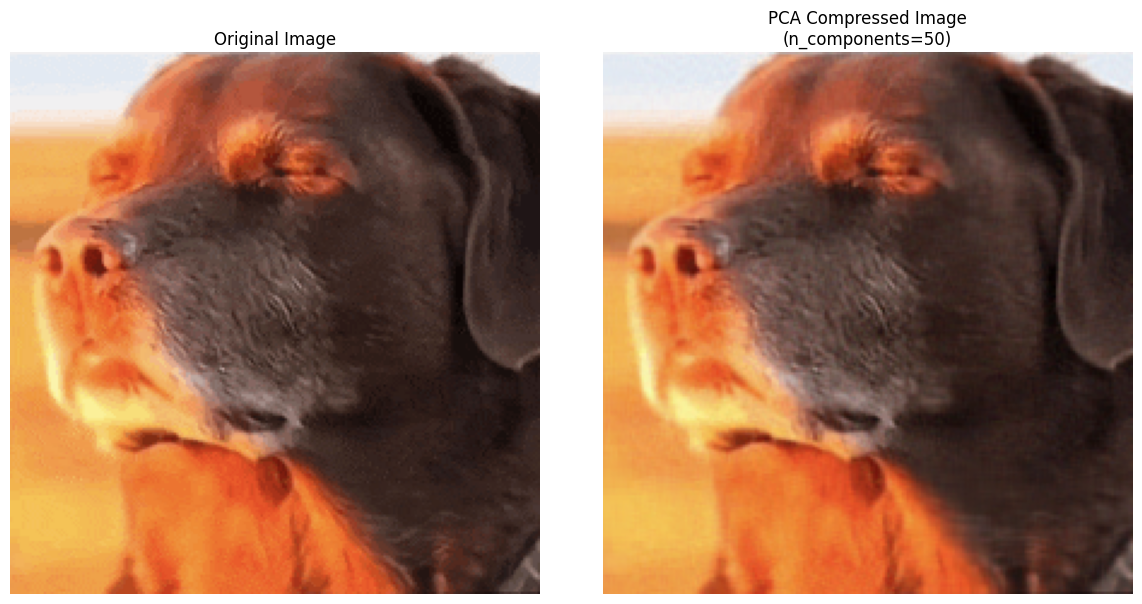

In [11]:
# 7. Image Compression
# Load image
img = cv2.imread("Doge.png")  
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w, c = img_rgb.shape

print(f"Original image shape: {img_rgb.shape}")

def pca_compress_per_channel(img, n_components=50):
    channels = []
    for i in range(3):
        channel = img[:, :, i].astype(np.float32)
        pca = PCA(n_components=min(n_components, channel.shape[1]))
        transformed = pca.fit_transform(channel)
        reconstructed = pca.inverse_transform(transformed)
        channels.append(reconstructed)
    compressed = np.stack(channels, axis=2)
    compressed = np.clip(compressed, 0, 255).astype(np.uint8)
    return compressed

# Compress
pca_img = pca_compress_per_channel(img_rgb, n_components=50)

# Convert back to BGR for saving with OpenCV
pca_img_bgr = cv2.cvtColor(pca_img, cv2.COLOR_RGB2BGR)

# Save compressed image
compressed_filename = "pca_compressed_image.jpg"
cv2.imwrite(compressed_filename, pca_img_bgr)

# Get file sizes in KB
original_size = os.path.getsize("Doge.png") / 1024
compressed_size = os.path.getsize(compressed_filename) / 1024

print(f"Original image file size: {original_size:.2f} KB")
print(f"Compressed image file size: {compressed_size:.2f} KB")

# Display original and compressed images side-by-side
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(pca_img)
plt.title(f"PCA Compressed Image\n(n_components=50)")
plt.axis('off')

plt.tight_layout()
plt.show()

### Note on File Size Comparison

The original image is a JPEG file, which uses advanced lossy compression techniques to reduce file size significantly.  
Our PCA-compressed image, although visually compressed, is reconstructed and saved without such optimized encoding by default.  
As a result, the PCA-compressed image file size may be larger than the original JPEG.  

To fairly compare file sizes, one should save both images using the same format and compression settings (e.g., PNG for lossless or JPEG with controlled quality).  
Additionally, raw array memory size (`numpy` array `.nbytes`) can be used to compare the actual data size in memory.

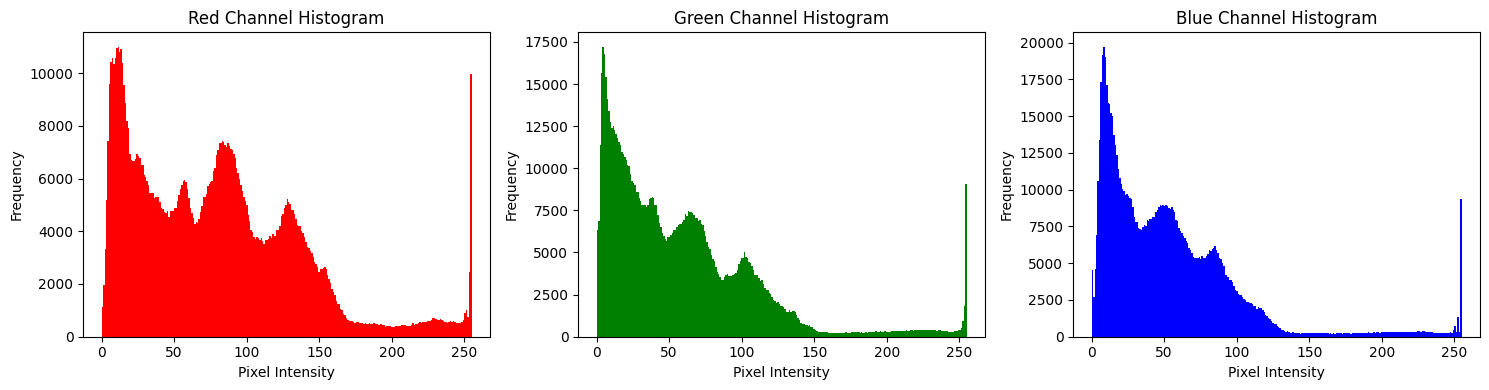

Standard Deviation (Contrast estimate) per channel:
Red channel: 57.87
Green channel: 51.79
Blue channel: 48.20
Entropy of Red channel after thresholding: 0.9490 bits
Entropy of Green channel after thresholding: 0.8191 bits
Entropy of Blue channel after thresholding: 0.8179 bits


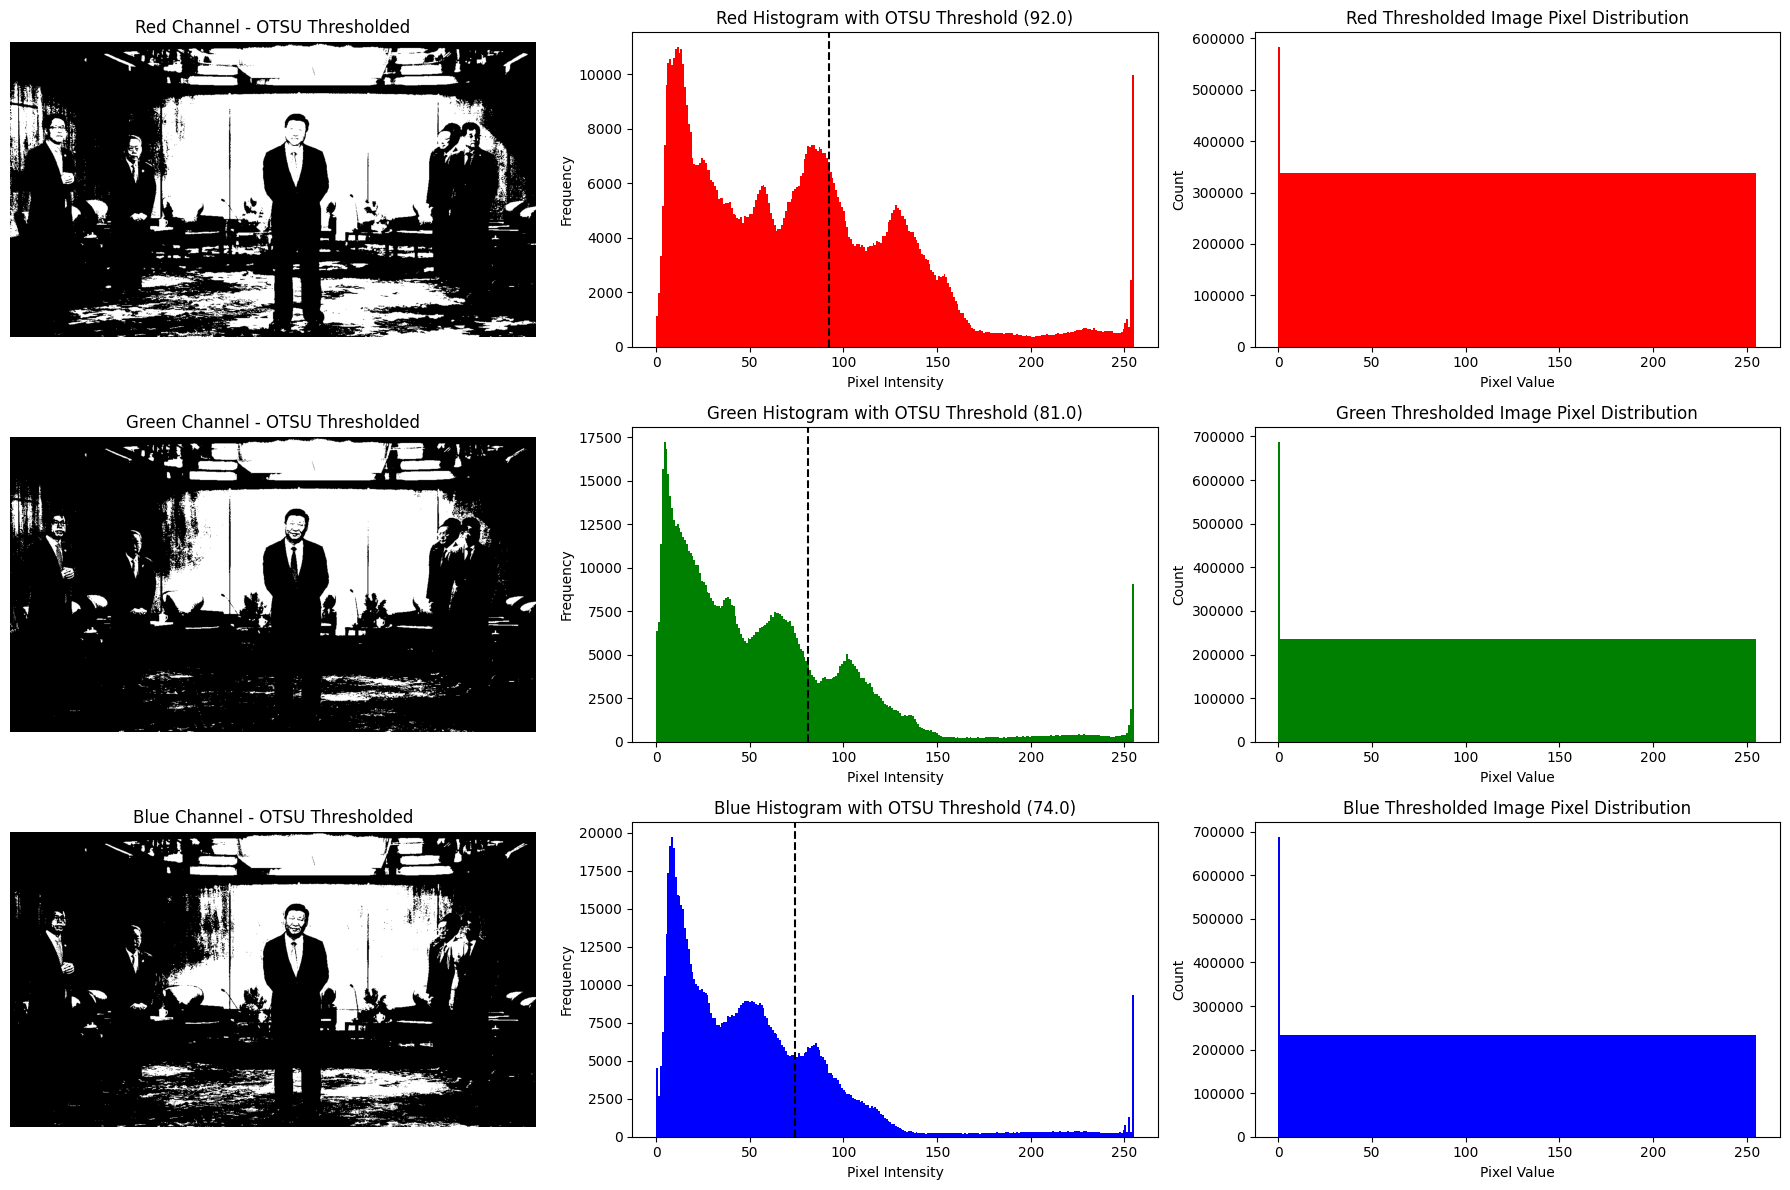

In [12]:
# 8. Color Image Processing
# Load image
img = cv2.imread("XiJingAura.png")  
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Split channels
R, G, B = cv2.split(img_rgb)

channels = {'Red': R, 'Green': G, 'Blue': B}

# Part i: Plot histograms 
plt.figure(figsize=(15,4))
for i, (ch_name, ch_data) in enumerate(channels.items(), 1):
    plt.subplot(1,3,i)
    plt.hist(ch_data.ravel(), bins=256, color=ch_name.lower())
    plt.title(f"{ch_name} Channel Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Part ii: Compute and print standard deviation 
print("Standard Deviation (Contrast estimate) per channel:")
for ch_name, ch_data in channels.items():
    std_val = np.std(ch_data)
    print(f"{ch_name} channel: {std_val:.2f}")

# Part iii: OTSU Thresholding and Evaluation 

def calculate_entropy(img_binary):
    # Flatten and count unique values (0 and 1)
    vals, counts = np.unique(img_binary.ravel(), return_counts=True)
    probs = counts / counts.sum()
    return scipy_entropy(probs, base=2)

plt.figure(figsize=(18,12))
for i, (ch_name, ch_data) in enumerate(channels.items(), 1):
    # Apply OTSU thresholding
    thresh_val = threshold_otsu(ch_data)
    binary_img = (ch_data >= thresh_val).astype(np.uint8) * 255

    # Plot thresholded image
    plt.subplot(3,3, (i-1)*3 + 1)
    plt.imshow(binary_img, cmap='gray')
    plt.title(f"{ch_name} Channel - OTSU Thresholded")
    plt.axis('off')

    # Plot histogram after thresholding with threshold line
    plt.subplot(3,3, (i-1)*3 + 2)
    plt.hist(ch_data.ravel(), bins=256, color=ch_name.lower())
    plt.axvline(thresh_val, color='k', linestyle='dashed', linewidth=1.5)
    plt.title(f"{ch_name} Histogram with OTSU Threshold ({thresh_val:.1f})")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")

    # Plot binary pixel value histogram (0 and 255)
    plt.subplot(3,3, (i-1)*3 + 3)
    plt.hist(binary_img.ravel(), bins=[0,1,255], color=ch_name.lower())
    plt.title(f"{ch_name} Thresholded Image Pixel Distribution")
    plt.xlabel("Pixel Value")
    plt.ylabel("Count")

    # Calculate and print entropy
    ent = calculate_entropy(binary_img // 255)
    print(f"Entropy of {ch_name} channel after thresholding: {ent:.4f} bits")

plt.tight_layout()
plt.show()

### Channel Histograms and Thresholding

- The **standard deviation** of an image channel represents how much intensity varies within that channel.  
  A higher standard deviation means greater contrast and more diverse intensity levels.

- **OTSU thresholding** works by finding a threshold that maximizes the variance between foreground and background, effectively separating the two regions.

- Channels that have **bimodal histograms**—those with two distinct peaks—usually yield better and more accurate thresholded results.

- The **entropy** of a binary mask is used to measure the level of randomness or uncertainty in the segmentation:
  - **Low entropy** (close to 0) indicates that the mask is mostly either foreground or background, suggesting a clean segmentation.
  - **Higher entropy** means the segmentation is more mixed or uncertain.

- However, **entropy should not be relied on alone**:
  - A low-entropy mask might still have poor segmentation if, for example, the foreground dominates the entire image.
  - Noisy images can have moderate entropy while still delivering low-quality segmentation.

- Therefore, to accurately assess the quality of thresholding, one should combine **quantitative measures** like entropy with **visual evaluation** of histograms and thresholded masks.

- Among the RGB channels, the one with the **highest standard deviation** and a **bimodal histogram** generally gives the best segmentation results using OTSU thresholding.